# Reto Spaceship Titanic - Avance 1

| | |
|---|---|
| **Equipo** | Israel González Huerta A01751433<br>Luis David Pozos Tamez A01800657<br>Adrián Proaño Bernal A01752615<br>Juan Pablo Solís Gómez A01800430<br>Karol Alexis Alvarado Davila A01751711 |
| **Fecha** | 31 de agosto de 2026 |

---

## 1. Carga y comprensión del dataset

### 1.1 Carga de `train.csv` y `test.csv`

Carga de los conjuntos de entrenamiento y prueba provistos por Kaggle. No se realiza split adicional: todo el trabajo de preparación se desarrolla sobre `train.csv`.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

import math

In [38]:
train = pd.read_csv('../data/titanic_data/train.csv')
test = pd.read_csv('../data/titanic_data/test.csv')

### 1.2 Inspección de estructura: shape, tipos de variables y primeras filas

Revisión del número de filas y columnas, tipos de datos (`dtypes`) por variable, y muestra de las primeras observaciones (`head`) para comprender el formato general del dataset.

In [39]:
print(test.shape)
print(train.shape)

(4277, 13)
(8693, 14)


In [40]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [41]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [42]:
train.dtypes

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

### 1.3 Identificación de la variable target y tipo de problema

`Transported` es nuestra variable objetivo. El problema que se está intentando resolver en este escenario es identificar a los pasajeros que fueron transportados a la dimensión alterna, por lo que cuadra perfectamente con el dato booleano que aparece en el training set. 

El tipo de problema al que nos enfrentamos es una **clasificación binaria supervisada**, ya que la predicción solo puede caer en dos categorías, y además tenemos acceso a una muestra con valores predefinidos de True/False para `Transported` (test.csv). A partir de esto podemos verificar algunas de las respuestas que da el modelo y proporcionarle retroalimentación.

## 2. Análisis exploratorio (EDA)

### 2.1 Valores faltantes: porcentaje por columna y clasificación (informativo vs. real)

Cálculo del porcentaje de faltantes por columna. Cada variable se clasifica como **faltante informativo** o **faltante real**, justificando cada clasificación con el contexto del dataset descrito en Kaggle.

In [43]:
faltantes = train.isnull().sum()
faltantes / len(train) * 100

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64

**Check extra:** confirmar la hipótesis acerca del CryoSleep. Los pasajeros no deberían de gastar si están en este estado

In [44]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
total_spend = train[spend_cols].sum(axis=1, skipna=True)
check = train.loc[train["CryoSleep"].notna() & (total_spend > 0), "CryoSleep"]
print((check == True).sum(), "de", len(check))
print(check.value_counts(dropna=False))

0 de 4921
CryoSleep
False    4921
Name: count, dtype: int64


**Tabla de clasificación de variables**

| Variable | Faltante | Justificación |
|---|---|---|
| CryoSleep | Faltante real  | Un pasajero dormido no puede consumir. Si el gasto es > 0, CryoSleep debe ser false. Entonces los casos faltantes, son un hueco. |
| ShoppingMall |Faltante informativo  | Siguiendo con el razonamiento anterior, si CyroSleep es true, ShoppingMall debe ser 0. Entonces el pasajero no gastó nada. Si CryoSleep es False o desconocido, es un faltante real que requiere imputación estadística (mediana condicionada a pasajeros despiertos).  |
| VIP | Faltante real  | No hay motivo lógico por el que la ausencia signifique algo sistinto a "no se capturó". |
| HomePlanet | Faltante real | Su ausencia es porque no se capturó. Puede ser posible recuperarla por relaciones de miembros del mosmo grupo, deck o cabin |
| Name | Faltante real | No es relevante. Su ausencia no aporta nada al target, además es un identificador casi único. |
| Cabin | Faltante real | Si falta, no afecta al target, puede ser una falta de captura y no necesariamente que el pasajero no tenga cabina. |
| VRDeck | Faltante informativo | Igual que ShoppingMall, si CryoSleep es true, tiene que ser 0. Se tendría que comprobar que el pasajero está o estuvo activo para imputar el faltante. |
| Spa | Faltante informativo | Igual que las otras amenidades. Debe ser 0 con CryoSleep true, y es faltante de captura en pasajeros activos. |
| FoodCourt | Faltante informativo  | Igual que las otras amenidades. Debe ser 0 con CryoSleep true, y es faltante de captura en pasajeros activos. |
| Destination | Faltante real | La ausencia es porque no se capturó. Nota (ver 3.1): esta fila se anotó originalmente como "el destino no aporta nada al target"; el crosstab de la sección 3.1 corrigió esa conclusión al mostrar una diferencia consistente con Transported. |
| RoomService | Faltante informativo | Igual que las otras amenidades. Debe ser 0 con CryoSleep true, y es faltante de captura en pasajeros activos. |
| Age | Faltante real | Al igual que el nombre, no hay razón por la que "sin edad" signifique algo. No tiene relación determinística con otras variables. |

### 2.2 Variables numéricas: distribución, skewness y outliers

Histogramas de las variables numéricas, cálculo de asimetría (skewness) y detección de outliers mediante el método de Tukey/rango intercuartílico (IQR).

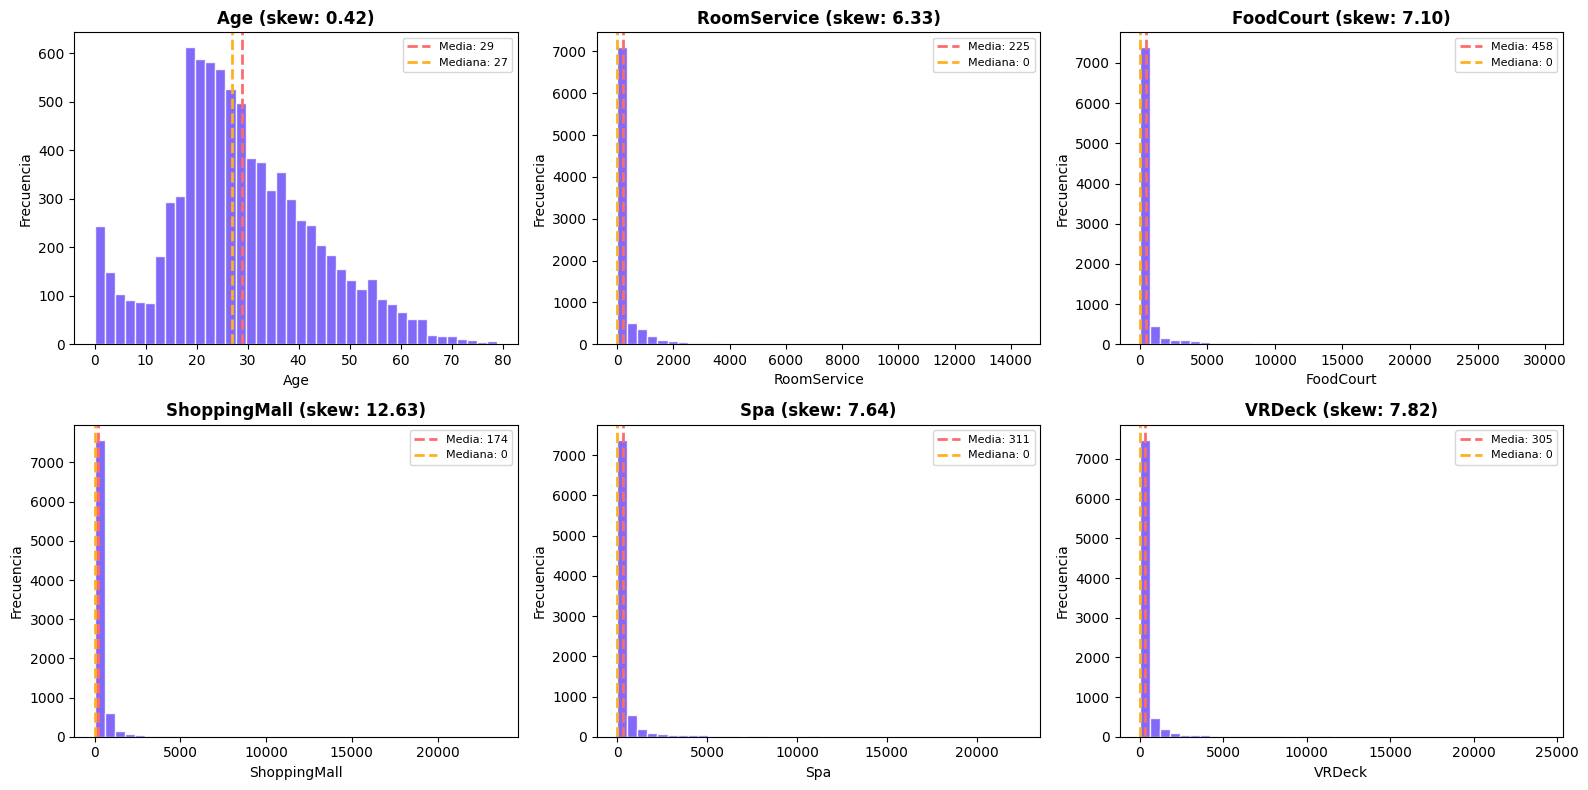

In [45]:
cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flat, cols):
    ax.hist(train[col].dropna(), bins=40, color='#6C4FF6', edgecolor='white', alpha=0.85)
    ax.axvline(train[col].mean(), color='#FF6B6B', linewidth=2,
               linestyle='--', label=f"Media: {train[col].mean():,.0f}")
    ax.axvline(train[col].median(), color='#FFB020', linewidth=2,
               linestyle='--', label=f"Mediana: {train[col].median():,.0f}")

    ax.set_title(f"{col} (skew: {train[col].skew():.2f})", fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [46]:
info_outliers = []

for col in cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = train[(train[col] < lim_inf) | (train[col] > lim_sup)]

    info_outliers.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Límite inferior': lim_inf,
        'Límite superior': lim_sup,
        'Num outliers': len(outliers),
        'Porcentaje outliers': len(outliers) / len(train) * 100
    })

outliers_df = pd.DataFrame(info_outliers)

outliers_df

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Num outliers,Porcentaje outliers
0,Age,19.0,38.0,19.0,-9.5,66.5,77,0.885770
1,RoomService,0.0,47.0,47.0,-70.5,117.5,1861,21.408029
2,FoodCourt,0.0,76.0,76.0,-114.0,190.0,1823,20.970896
3,ShoppingMall,0.0,27.0,27.0,-40.5,67.5,1829,21.039917
4,Spa,0.0,59.0,59.0,-88.5,147.5,1788,20.568273
5,VRDeck,0.0,46.0,46.0,-69.0,115.0,1809,20.809847


### 2.3 Variables categóricas: cardinalidad, distribución y desbalance

Análisis de la cardinalidad de cada variable categórica, distribución de sus categorías y detección de variables con desbalance extremo entre clases.

In [47]:
v_categoricas = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin']

""" for col in v_categoricas:
    print(f"Valores en {col}:")
    print(train[col].value_counts())
 """

cardinalidad = train[v_categoricas].nunique().sort_values(ascending=False)
cardinalidad

Cabin          6560
HomePlanet        3
Destination       3
CryoSleep         2
VIP               2
dtype: int64

Cabin tiene una cardinalidad demasiado alta, pero es una variable compuesta. Podemos separar Deck, Side y NumCabin para analizar si alguna de estas variables tiene una cardinalidad más baja y que pueda ser de verdadera utilidad para el modelo.

In [48]:
train[['Deck', 'NumCabin', 'Side']] = train['Cabin'].str.split('/', expand=True)
train['NumCabin'] = pd.to_numeric(train['NumCabin'])

test[['Deck', 'NumCabin', 'Side']] = test['Cabin'].str.split('/', expand=True)
test['NumCabin'] = pd.to_numeric(test['NumCabin'])

Comprobamos la cardinalidad otra vez con las nuevas columnas:

In [49]:
v_categoricas = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'NumCabin', 'Deck', 'Side']

cardinalidad = train[v_categoricas].nunique().sort_values(ascending=False)
cardinalidad

NumCabin       1817
Deck              8
HomePlanet        3
Destination       3
CryoSleep         2
VIP               2
Side              2
dtype: int64

### 2.4 Relación de cada variable con el target

Crosstabs entre variables categóricas y `Transported`, y boxplots de variables numéricas segmentados por `Transported`. Este análisis es la base para justificar qué variables entran y cuáles se descartan en la siguiente etapa. Se excluye NumCabin por cardinalidad

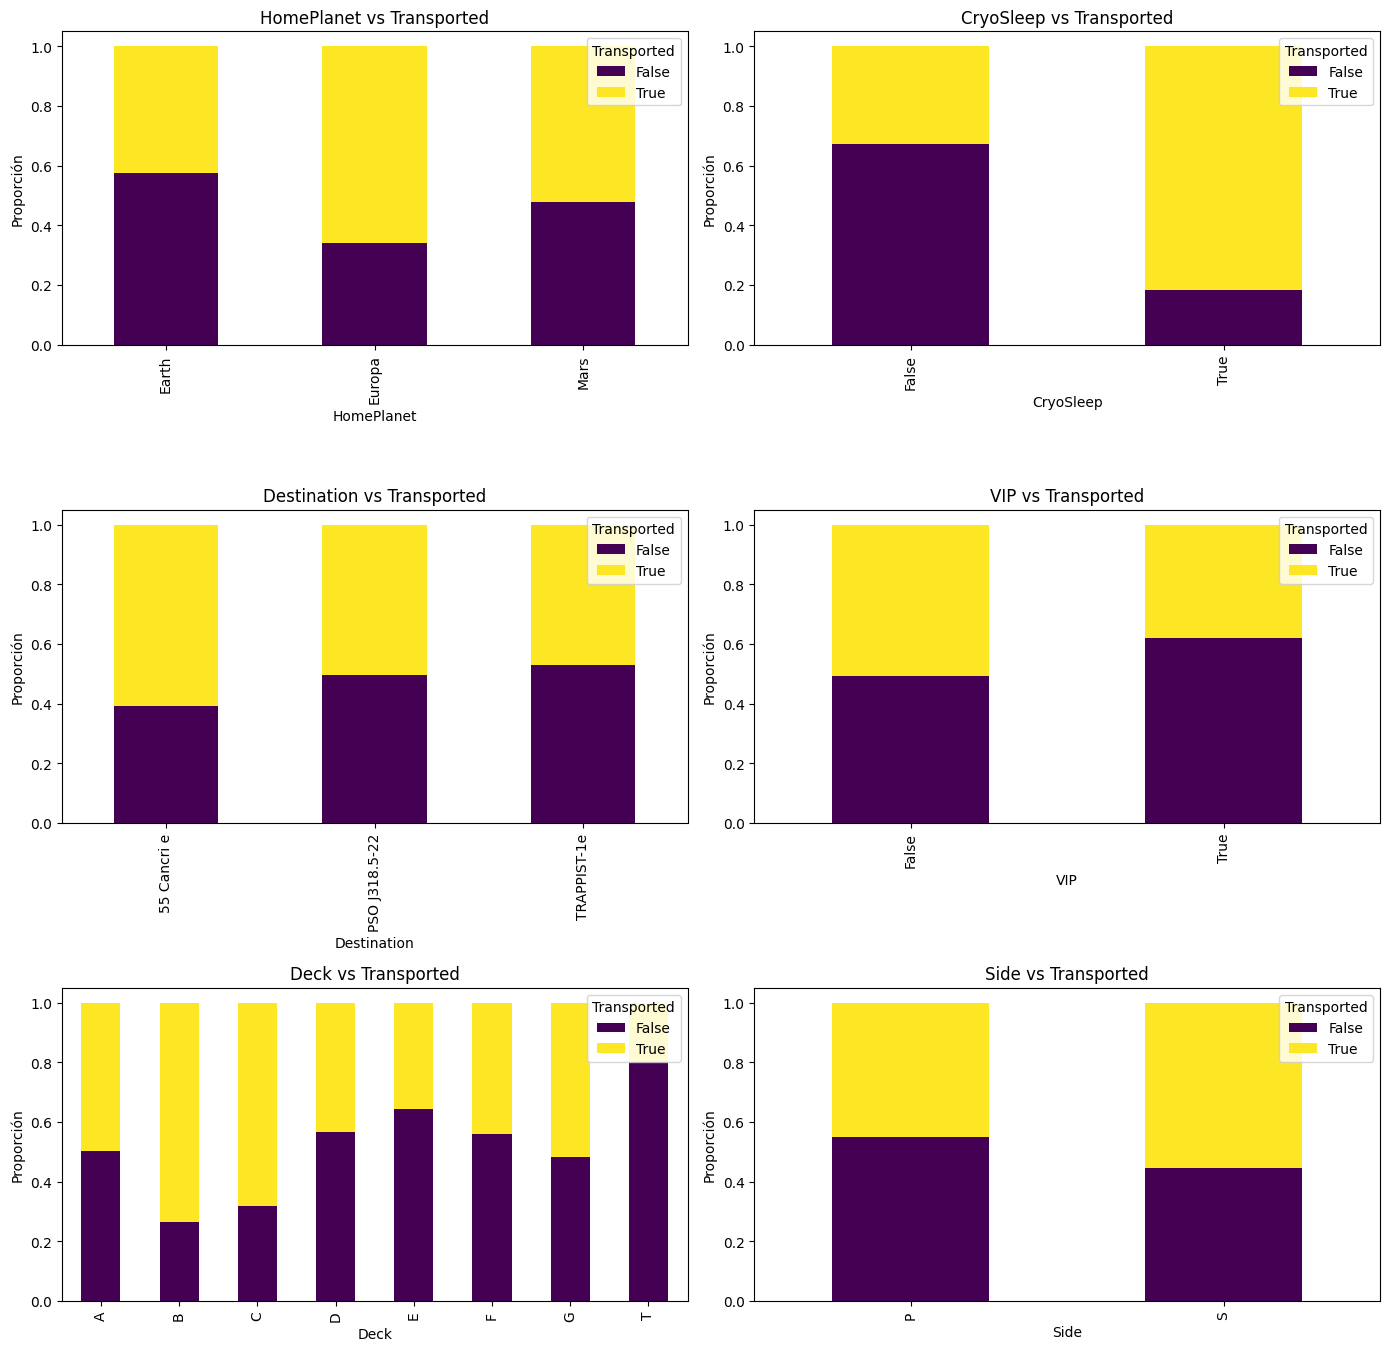

In [50]:
v_categoricas_crosstabs = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(v_categoricas_crosstabs):
    ct = pd.crosstab(train[col], train['Transported'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')
    axes[i].set_title(f'{col} vs Transported')
    axes[i].set_ylabel('Proporción')
    axes[i].legend(title='Transported', loc='upper right')

for j in range(len(v_categoricas_crosstabs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

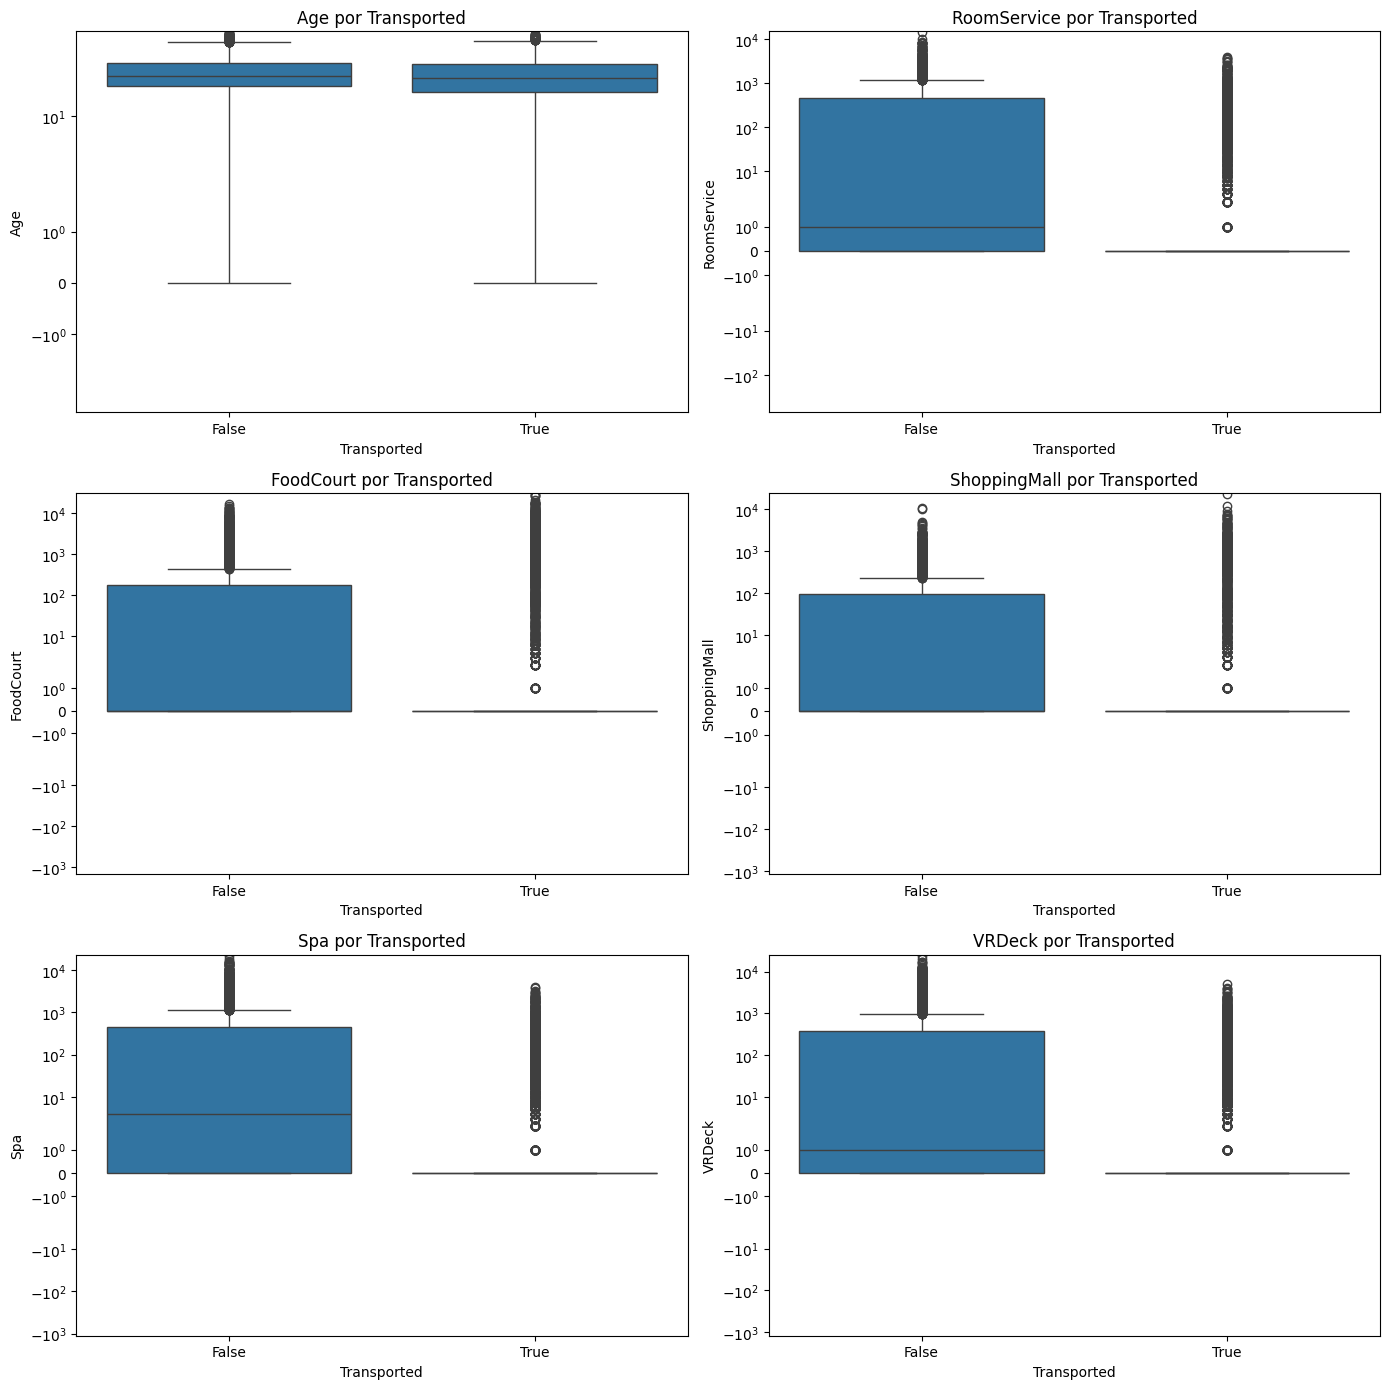

In [51]:
v_numericas = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(v_numericas):
    sns.boxplot(data=train, x='Transported', y=col, ax=axes[i])
    axes[i].set_title(f'{col} por Transported')
    axes[i].set_yscale('symlog')

plt.tight_layout()
plt.show()

## 3. Selección y descarte de variables

### 3.1 Variables incluidas en el pipeline

Listado de variables que se conservan para el modelado, con la evidencia del EDA que respalda cada inclusión (relación con el target, faltantes manejables, cardinalidad razonable, etc.).

In [52]:
v_conservar = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'Deck',
    'Side',
    'NumCabin',   
]

v_descartar = [
    'PassengerId', 
    'Name', 
    'Age', 
    'VIP',
    'Cabin'
]

v_binarizar = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
]

Las seis variables que se conservan son las que muestran una separación visible en los crosstabs de la sección 2.4 y que además tienen una cardinalidad que el modelo puede manejar.

**CryoSleep** es la variable con la relación más fuerte con el target. En su crosstab la barra se parte casi en dos bloques distintos: la proporción de transportados entre los pasajeros dormidos está muy por encima de la de los pasajeros despiertos. Además solo tiene 2 categorías y 2.50% de faltantes, que son recuperables con la regla del gasto que ya validamos en la sección 2.1.

**HomePlanet** separa bien a los tres planetas. Europa queda arriba de la media, Earth abajo y Mars en medio, y la diferencia entre los extremos es grande. Con 3 categorías y 2.31% de faltantes, es de las variables más baratas de incluir.

**Destination** en la sección 2.1 la habíamos anotado como poco relevante, pero el crosstab muestra que 55 Cancri e tiene una proporción de transportados claramente mayor que TRAPPIST-1e. La diferencia es menor que la de CryoSleep, pero es consistente, y con 3 categorías y 2.09% de faltantes el costo de conservarla es mínimo. Se corrige entonces la anotación previa y la variable entra al pipeline.

**Deck** tiene 8 categorías y es la que más se benefició de haber descompuesto Cabin. Las cubiertas B y C están claramente arriba y E y F abajo, así que la variable aporta señal propia. La cubierta T casi no tiene pasajeros, pero eso no invalida al resto de las categorías.

**Side** solo tiene 2 categorías y la diferencia entre estribor y babor es pequeña, pero es limpia y constante. Con cardinalidad 2, incluirla cuesta una sola columna.

**NumCabin** tiene 1817 valores distintos, así que no se puede usar tal cual. Se conserva porque el número de cabina ordena físicamente las cabinas dentro de cada deck, y pasajeros con números cercanos viajaron juntos en la misma zona de la nave. Esperamos que esa vecindad conserve señal una vez agrupada en rangos, que es lo que se hace en la sección 5.2.

### 3.2 Variables descartadas

Listado de variables excluidas del pipeline, justificando cada descarte con evidencia concreta: porcentaje de faltantes, desbalance extremo, ausencia de relación con el target, cardinalidad excesiva o redundancia con otra variable.

**PassengerId** es un identificador y tiene tantos valores distintos como filas. La primera parte del id corresponde al grupo con el que viajó el pasajero y en principio podría explotarse, pero como columna directa no aporta nada y no se puede codificar. Se descarta.

**Name** tiene 2.30% de faltantes y es prácticamente único por pasajero, así que es la variable de mayor cardinalidad del dataset. No guarda relación con el target y cualquier codificación produciría miles de columnas vacías.

**Age** está limpia: solo 0.89% de outliers, muy por debajo del 20% de las variables de gasto, y 2.06% de faltantes. El problema es que no separa. En los boxplots de la sección 2.4 las cajas de Transported true y false quedan prácticamente encimadas, con la misma mediana, el mismo rango intercuartílico y bigotes casi idénticos. Es una variable limpia pero sin señal, así que se descarta.

**VIP** tiene desbalance extremo: menos del 3% de los pasajeros son VIP. Sobre una base tan chica, cualquier diferencia en la proporción de transportados es poco confiable, y en el crosstab la separación tampoco es grande. Sumando 2.34% de faltantes, no se justifica imputarla para conservar una columna casi constante.

**Cabin** se descarta como columna original porque ya quedó descompuesta en Deck, NumCabin y Side. Con 6560 valores distintos es inutilizable tal cual, y mantenerla junto a sus tres componentes sería pura redundancia.

In [53]:
# Por ahora, conservamos Passenger ID que puede ser útil para el match con el testing set, pero se descarta en el modelo final.
v_descartar = [
    'Name', 
    'Age', 
    'VIP',
    'Cabin'
]

train = train.drop(columns=v_descartar)

### 3.3 Evaluación de binarización para variables con desbalance extremo

Antes de descartar variables con clases muy desbalanceadas (por ejemplo, servicios de gasto a bordo), se evalúa si transformarlas en indicadores binarios (`HasPool`, `HasCabin`, etc.) preserva señal útil para el target.

Las cinco variables de gasto tienen más de 20% de outliers por IQR y un sesgo muy alto, pero eso no significa que no sirvan. Lo que probablemente separa a los pasajeros no es cuánto gastaron sino si gastaron algo, porque el gasto en cero es justamente la huella que deja CryoSleep. Antes de decidir si se descartan, comparamos la proporción de transportados entre los pasajeros que gastaron cero y los que gastaron más de cero en cada servicio.

In [54]:
resumen_bin = []

for col in v_binarizar:
    ind = train[col].fillna(0) > 0

    resumen_bin.append({
        'Variable': col,
        'Pasajeros con gasto': ind.sum(),
        'Transportados sin gasto': train.loc[~ind, 'Transported'].mean(),
        'Transportados con gasto': train.loc[ind, 'Transported'].mean()
    })

resumen_bin = pd.DataFrame(resumen_bin)

resumen_bin

,Variable,Pasajeros con gasto,Transportados sin gasto,Transportados con gasto
0,RoomService,2935,0.627822,0.259966
1,FoodCourt,3054,0.589289,0.345449
2,ShoppingMall,2898,0.596894,0.317115
3,Spa,3186,0.634465,0.277464
4,VRDeck,3010,0.624494,0.275415


La binarización sí conserva señal, y en varios servicios la separación es más fuerte que la de muchas variables categóricas. En RoomService, Spa y VRDeck los pasajeros que gastaron algo se transportan bastante menos que los que no gastaron nada, mientras que en FoodCourt y ShoppingMall la diferencia va en el otro sentido o es más suave. El corte en cero recupera casi toda la separación sin arrastrar el sesgo ni los outliers, así que cada variable de gasto se convierte en un indicador binario (UsoRoomService, UsoFoodCourt, UsoShoppingMall, UsoSpa y UsoVRDeck).

## 4. Manejo de faltantes

### 4.1 Imputación de faltantes informativos

Estrategia de imputación aplicada a las variables cuyo faltante fue clasificado como informativo en el paso 2.1 (por ejemplo, imputación condicionada al valor de otra variable relacionada), con su justificación.

| Variable | % Faltantes | Estrategia de imputación | Justificación |
|---|---|---|---|
| RoomService | 2.08% | 1) Si `CryoSleep == True` → imputar 0. 2) Si `CryoSleep == False` → imputar con la mediana de la columna calculada solo sobre pasajeros despiertos (`CryoSleep == False`). 3) Si `CryoSleep` también es faltante, se asume "despierto" (criterio conservador) y se aplica el paso 2. | El check de 2.1 confirmó que 0 de 4921 pasajeros en CryoSleep gastaron algo: el 0 es determinístico, no una estimación. La mediana condicionada evita contaminar la imputación con el pico de ceros que aportan los pasajeros dormidos. |
| FoodCourt | 2.11% | Misma regla que RoomService (pasos 1-3). |  |
| ShoppingMall | 2.39% | Misma regla que RoomService (pasos 1-3). |  |
| Spa | 2.11% | Misma regla que RoomService (pasos 1-3). |  |
| VRDeck | 2.16% | Misma regla que RoomService (pasos 1-3). |  |

### 4.2 Imputación de faltantes reales

Estrategia de imputación aplicada a las variables con faltantes reales (por ejemplo, medidas de tendencia central para numéricas o moda/categoría "Unknown" para categóricas), con su justificación.

| Variable | % Faltantes | Estrategia de imputación | Justificación |
|---|---|---|---|
| CryoSleep | 2.50% | 1) Si el gasto total (`RoomService+FoodCourt+ShoppingMall+Spa+VRDeck`) > 0 → `False` (regla determinística). 2) Si el gasto total es 0 o también falta → imputar con la moda global de `CryoSleep`. | El check de 2.1 valida el paso 1 en sentido inverso (gasto > 0 excluye CryoSleep=True). El paso 2 es un faltante genuino sin otra señal disponible una vez agotada la regla de gasto. |
| HomePlanet | 2.31% | 1) Imputar con la moda de `HomePlanet` condicionada al `Deck`. 2) Si el `Deck` también falta, usar la moda global. | El crosstab de 2.4 muestra que ciertos decks están asociados casi exclusivamente a un `HomePlanet`. No se usa `PassengerId` porque esa columna se descarta en la sección 3. |
| Destination | 2.09% | Imputar con la moda global (`TRAPPIST-1e`). | En 2.1 se concluyó que Destination no aporta señal relevante al target, por lo que no se justifica una imputación condicionada más compleja. |
| Deck | 2.29% (heredado de `Cabin`) | 1) Imputar con la moda de `Deck` condicionada a `HomePlanet` (ya imputado). 2) Si no hay dato, usar la moda global de `Deck`. | `Deck` está correlacionado con `HomePlanet` (evidencia de los crosstabs en 2.4). No se usa `PassengerId` porque esa columna se descarta en la sección 3. |
| Side | 2.29% (heredado de `Cabin`) | Imputar con la moda global de `Side`. | `Side` no mostró relación fuerte con el target en 2.4, por lo que basta la moda global. No se usa `PassengerId` porque esa columna se descarta en la sección 3. |
| NumCabin | 2.29% (heredado de `Cabin`) | Imputar con la mediana de `NumCabin` dentro del mismo `Deck` (ya imputado); si el `Deck` también es faltante, usar la mediana global. | Es una variable de alta cardinalidad pero con estructura por rangos dentro de cada deck; la mediana condicionada preserva mejor la posición relativa que una mediana global. |

### 4.3 Resumen de estrategia de imputación por variable

Tabla o resumen que consolida, por variable, el tipo de faltante y la estrategia de imputación elegida, evitando aplicar un único criterio genérico sin argumento.

| Variable | Tipo de faltante | Estrategia de imputación (resumen) | Justificación |
|---|---|---|---|
| CryoSleep | Real | Regla por gasto total (>0 → False); si no, moda global | Confirmada por el check de 2.1; sin otra señal disponible para el resto |
| HomePlanet | Real | Moda por `Deck` → moda global | Los decks comparten planeta de origen (2.4); no depende de `PassengerId` (se descarta en 3.2) |
| Destination | Real | Moda global (`TRAPPIST-1e`) | Sin relación con el target (2.1); no amerita imputación condicionada |
| Deck | Real (heredado de `Cabin`) | Moda por `HomePlanet` → moda global | Correlación con `HomePlanet` (2.4); no depende de `PassengerId` |
| Side | Real (heredado de `Cabin`) | Moda global | Sin relación fuerte con el target (2.4); no depende de `PassengerId` |
| NumCabin | Real (heredado de `Cabin`) | Mediana condicionada al `Deck` → mediana global | Alta cardinalidad con estructura por rangos dentro de cada deck |
| RoomService | Informativo | `CryoSleep`=True → 0; si no, mediana de despiertos | 0 de 4921 dormidos gastaron algo (check de 2.1) |
| FoodCourt | Informativo | Misma regla que RoomService | Misma dependencia estructural con `CryoSleep` |
| ShoppingMall | Informativo | Misma regla que RoomService |  |
| Spa | Informativo | Misma regla que RoomService |  |
| VRDeck | Informativo | Misma regla que RoomService |  |

In [55]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

gasto_total_original = train[spend_cols].sum(axis=1, skipna=True)

dormido = train["CryoSleep"] == True
despierto_o_faltante = train["CryoSleep"].fillna(False) == False

for col in spend_cols:
    mediana_despiertos = train.loc[despierto_o_faltante & train[col].notna(), col].median()
    falta = train[col].isna()
    train.loc[falta & dormido, col] = 0
    train.loc[falta & despierto_o_faltante, col] = mediana_despiertos

falta_cryo = train["CryoSleep"].isna()
train.loc[falta_cryo & (gasto_total_original > 0), "CryoSleep"] = False
train["CryoSleep"] = train["CryoSleep"].fillna(train["CryoSleep"].mode()[0])

def moda_por_grupo(serie):
    return serie.mode().iloc[0] if serie.notna().any() else np.nan

train["HomePlanet"] = train["HomePlanet"].fillna(
    train.groupby("Deck")["HomePlanet"].transform(moda_por_grupo)
)
train["HomePlanet"] = train["HomePlanet"].fillna(train["HomePlanet"].mode()[0])

train["Destination"] = train["Destination"].fillna(train["Destination"].mode()[0])

train["Deck"] = train["Deck"].fillna(
    train.groupby("HomePlanet")["Deck"].transform(moda_por_grupo)
)
train["Deck"] = train["Deck"].fillna(train["Deck"].mode()[0])

train["Side"] = train["Side"].fillna(train["Side"].mode()[0])

train["NumCabin"] = train["NumCabin"].fillna(
    train.groupby("Deck")["NumCabin"].transform("median")
)
train["NumCabin"] = train["NumCabin"].fillna(train["NumCabin"].median())

train.isnull().sum()

C:\Users\karal\AppData\Local\Temp\ipykernel_44792\3339307717.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  despierto_o_faltante = train["CryoSleep"].fillna(False) == False
C:\Users\karal\AppData\Local\Temp\ipykernel_44792\3339307717.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train["CryoSleep"] = train["CryoSleep"].fillna(train["CryoSleep"].mode()[0])


PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Deck            0
NumCabin        0
Side            0
dtype: int64

In [56]:
# convertir indicadores binarios
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

for col in spend_cols:
    train[f"Uso{col}"] = (train[col] > 0).astype(int)

train = train.drop(columns=spend_cols)

## 5. Codificación de variables categóricas

### 5.1 Codificación de variables nominales

Aplicación de codificación a variables categóricas sin orden natural, justificando la elección según cardinalidad y naturaleza de cada variable.

In [57]:
train = pd.get_dummies(train, columns=['HomePlanet', 'Destination', 'Deck'], drop_first=True)
train['Side'] = train['Side'].map({'P': 0, 'S': 1})
train['CryoSleep'] = train['CryoSleep'].astype(int)

train

,PassengerId,CryoSleep,Transported,NumCabin,Side,UsoRoomService,UsoFoodCourt,UsoShoppingMall,UsoSpa,UsoVRDeck,...,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T
0,0001_01,0,False,0.0,0,0,0,0,0,0,...,False,False,True,True,False,False,False,False,False,False
1,0002_01,0,True,0.0,1,1,1,1,1,1,...,False,False,True,False,False,False,False,True,False,False
2,0003_01,0,False,0.0,1,1,1,0,1,1,...,False,False,True,False,False,False,False,False,False,False
3,0003_02,0,False,0.0,1,0,1,1,1,1,...,False,False,True,False,False,False,False,False,False,False
4,0004_01,0,True,1.0,1,1,1,1,1,1,...,False,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,0,False,98.0,0,0,1,0,1,1,...,False,False,False,False,False,False,False,False,False,False
8689,9278_01,1,False,1499.0,1,0,0,0,0,0,...,False,True,False,False,False,False,False,False,True,False
8690,9279_01,0,True,1500.0,1,0,0,1,1,0,...,False,False,True,False,False,False,False,False,True,False
8691,9280_01,0,False,608.0,1,0,1,0,1,1,...,False,False,False,False,False,False,True,False,False,False


### 5.2 Codificación de variables ordinales

Evaluación de si alguna variable categórica presenta orden natural y, de ser así, aplicación de una codificación ordinal justificada.

In [58]:
bins = [0, 300, 600, 900, 1200, 1500, 1800, train['NumCabin'].max()+1]
train['NumCabin_bin'] = pd.cut(train['NumCabin'], bins=bins, labels=False, include_lowest=True)
train

,PassengerId,CryoSleep,Transported,NumCabin,Side,UsoRoomService,UsoFoodCourt,UsoShoppingMall,UsoSpa,UsoVRDeck,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,NumCabin_bin
0,0001_01,0,False,0.0,0,0,0,0,0,0,...,False,True,True,False,False,False,False,False,False,0
1,0002_01,0,True,0.0,1,1,1,1,1,1,...,False,True,False,False,False,False,True,False,False,0
2,0003_01,0,False,0.0,1,1,1,0,1,1,...,False,True,False,False,False,False,False,False,False,0
3,0003_02,0,False,0.0,1,0,1,1,1,1,...,False,True,False,False,False,False,False,False,False,0
4,0004_01,0,True,1.0,1,1,1,1,1,1,...,False,True,False,False,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,0,False,98.0,0,0,1,0,1,1,...,False,False,False,False,False,False,False,False,False,0
8689,9278_01,1,False,1499.0,1,0,0,0,0,0,...,True,False,False,False,False,False,False,True,False,4
8690,9279_01,0,True,1500.0,1,0,0,1,1,0,...,False,True,False,False,False,False,False,True,False,4
8691,9280_01,0,False,608.0,1,0,1,0,1,1,...,False,False,False,False,False,True,False,False,False,2


### 5.3 Verificación de ausencia de columnas tipo `object`

Comprobación de que, tras la codificación, ninguna columna del dataset conserva el tipo `object`.

In [59]:
cols_object = train.drop(columns=['PassengerId']).select_dtypes(include='object').columns.tolist()
assert len(cols_object) == 0, f"Aún quedan columnas tipo object: {cols_object}"
train

,PassengerId,CryoSleep,Transported,NumCabin,Side,UsoRoomService,UsoFoodCourt,UsoShoppingMall,UsoSpa,UsoVRDeck,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,NumCabin_bin
0,0001_01,0,False,0.0,0,0,0,0,0,0,...,False,True,True,False,False,False,False,False,False,0
1,0002_01,0,True,0.0,1,1,1,1,1,1,...,False,True,False,False,False,False,True,False,False,0
2,0003_01,0,False,0.0,1,1,1,0,1,1,...,False,True,False,False,False,False,False,False,False,0
3,0003_02,0,False,0.0,1,0,1,1,1,1,...,False,True,False,False,False,False,False,False,False,0
4,0004_01,0,True,1.0,1,1,1,1,1,1,...,False,True,False,False,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,0,False,98.0,0,0,1,0,1,1,...,False,False,False,False,False,False,False,False,False,0
8689,9278_01,1,False,1499.0,1,0,0,0,0,0,...,True,False,False,False,False,False,False,True,False,4
8690,9279_01,0,True,1500.0,1,0,0,1,1,0,...,False,True,False,False,False,False,False,True,False,4
8691,9280_01,0,False,608.0,1,0,1,0,1,1,...,False,False,False,False,False,True,False,False,False,2


## 6. Transformación de variables numéricas

### 6.1 Evaluación del sesgo (skewness)

Revisión del coeficiente de asimetría de cada variable numérica para identificar cuáles presentan sesgo significativo.

In [60]:
v_continuas = ['NumCabin']

resumen_sesgo = pd.DataFrame({
    'Skewness': train[v_continuas].skew(),
    'Media': train[v_continuas].mean(),
    'Mediana': train[v_continuas].median(),
    'Maximo': train[v_continuas].max(),
    '% ceros': (train[v_continuas] == 0).mean() * 100
})

resumen_sesgo['Sesgo relevante'] = resumen_sesgo['Skewness'].abs() > 1

resumen_sesgo

,Skewness,Media,Mediana,Maximo,% ceros,Sesgo relevante
NumCabin,0.714676,600.452836,435.0,1894.0,0.207063,False


Solo se evalúan las variables continuas que quedaron vivas después de la sección 5. CryoSleep, Side y las dummies de HomePlanet, Destination y Deck son binarias: su asimetría refleja el desbalance de clases, no un sesgo corregible con una transformación, y aplicarles una sería tratarlas como magnitudes cuando solo son indicadores. NumCabin_bin tampoco entra porque es una codificación ordinal ya acotada a siete niveles, y PassengerId es identificador.

El criterio para marcar sesgo relevante es un valor absoluto de skewness mayor a 1, el umbral convencional para asimetría fuerte. Las cinco variables de gasto ya no aparecen en esta tabla: se convirtieron en indicadores binarios en la sección 3.3, justo después de la imputación de la sección 4 y antes de la codificación de la sección 5, así que nunca llegan a evaluarse aquí como continuas. La única variable evaluada es NumCabin, que se reparte de forma casi uniforme a lo largo de la nave y tiene una asimetría despreciable, así que no requiere transformación.

### 6.2 Aplicación de transformaciones justificadas

Aplicación de una transformación (p. ej. logarítmica o `PowerTransformer`) a las variables con sesgo relevante, justificando la elección según el tipo y grado de sesgo detectado.

Tras la binarización de la sección 3.3, ninguna variable queda marcada con sesgo relevante (`v_transformar` resulta una lista vacía): las cinco variables de gasto ya son indicadores 0/1 y NumCabin no supera el umbral de skewness definido en 6.1. Por lo tanto no hay nada que transformar ni que comparar entre log1p y Yeo-Johnson; la tabla de la celda siguiente queda vacía a propósito, como constancia de que el paso se evaluó y no aplica.

In [61]:
from sklearn.preprocessing import PowerTransformer

v_transformar = resumen_sesgo.index[resumen_sesgo['Sesgo relevante']].tolist()

if v_transformar:
    skew_log1p = np.log1p(train[v_transformar]).skew()

    yeo = PowerTransformer(method='yeo-johnson', standardize=False)
    skew_yeo = pd.DataFrame(
        yeo.fit_transform(train[v_transformar]),
        columns=v_transformar,
        index=train.index
    ).skew()

    comparacion_metodos = pd.DataFrame({
        'Skew original': train[v_transformar].skew(),
        'Skew log1p': skew_log1p,
        'Skew Yeo-Johnson': skew_yeo
    })
else:
    comparacion_metodos = pd.DataFrame(columns=['Skew original', 'Skew log1p', 'Skew Yeo-Johnson'])

comparacion_metodos


,Skew original,Skew log1p,Skew Yeo-Johnson


No se aplica ninguna transformación en esta sección: las cinco variables de gasto se convirtieron en indicadores binarios en la sección 3.3 y no necesitan corrección de sesgo, y NumCabin se deja sin transformar porque su asimetría ya es despreciable (6.1).

In [62]:
train_sin_transformar = train[v_transformar].copy()

train[v_transformar] = np.log1p(train[v_transformar])

resumen_transformacion = pd.DataFrame({
    'Skew original': train_sin_transformar.skew(),
    'Skew transformado': train[v_transformar].skew(),
    'Maximo original': train_sin_transformar.max(),
    'Maximo transformado': train[v_transformar].max(),
    '% ceros (se conserva)': (train[v_transformar] == 0).mean() * 100
})

resumen_transformacion

,Skew original,Skew transformado,Maximo original,Maximo transformado,% ceros (se conserva)


### 6.3 Comparación de distribuciones antes y después

Visualización comparativa (histogramas) de cada variable transformada, mostrando su distribución original frente a la distribución tras la transformación.

In [63]:
if v_transformar:
    fig, axes = plt.subplots(nrows=len(v_transformar), ncols=2,
                             figsize=(14, 3.2 * len(v_transformar)))

    for i, col in enumerate(v_transformar):
        axes[i, 0].hist(train_sin_transformar[col], bins=40,
                        color='#6C4FF6', edgecolor='white', alpha=0.85)
        axes[i, 0].set_title(f"{col} original (skew: {train_sin_transformar[col].skew():.2f})",
                             fontsize=11, fontweight='bold')
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel('Frecuencia')

        axes[i, 1].hist(train[col], bins=40,
                        color='#FFB020', edgecolor='white', alpha=0.85)
        axes[i, 1].set_title(f"{col} tras log1p (skew: {train[col].skew():.2f})",
                             fontsize=11, fontweight='bold')
        axes[i, 1].set_xlabel(f"log1p({col})")
        axes[i, 1].set_ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()
else:
    print("No hay variables en v_transformar: nada que comparar antes/después.")

No hay variables en v_transformar: nada que comparar antes/después.


No hay histogramas que mostrar en esta sección: al no haber ninguna variable en `v_transformar` (las cinco variables de gasto quedaron binarizadas en 3.3, y NumCabin no necesitó transformación según 6.1), no existe una comparación antes/después que hacer. La celda de arriba queda vacía a propósito, como constancia de que el paso se evaluó.

## 7. Escalado

### 7.1 Selección del escalador según presencia de outliers

Decisión entre `StandardScaler` y `RobustScaler` (u otra alternativa) para cada grupo de variables numéricas, en función de la presencia de outliers detectada en el paso 2.2.

In [64]:
v_escalar = v_continuas + ['NumCabin_bin']

def pct_outliers(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        return np.nan
    return ((serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)).mean() * 100

diagnostico_escalado = pd.DataFrame({
    'Skew': train[v_escalar].skew(),
    '% outliers IQR': [pct_outliers(train[col]) for col in v_escalar],
    'Media': train[v_escalar].mean(),
    'Mediana': train[v_escalar].median(),
    'Min': train[v_escalar].min(),
    'Max': train[v_escalar].max()
})

diagnostico_escalado

,Skew,% outliers IQR,Media,Mediana,Min,Max
NumCabin,0.714676,0.0,600.452836,435.0,0.0,1894.0
NumCabin_bin,0.768610,0.0,1.522259,1.0,0.0,6.0


El diagnóstico se recalcula después de transformar, no sobre los valores originales: escalar es el último paso y lo que importa es la forma que tienen las variables al llegar a él, no la que tenían en la sección 2.2.

Las cinco variables de gasto no aparecen en este diagnóstico ni en el escalado: quedaron como indicadores binarios (UsoRoomService, UsoFoodCourt, UsoShoppingMall, UsoSpa, UsoVRDeck) tras la binarización de la sección 3.3, fuera de `v_continuas`.

A NumCabin y NumCabin_bin, que describen la posición del pasajero dentro de la nave, se les aplica StandardScaler. Sus distribuciones son casi uniformes y sin outliers por IQR: NumCabin no tiene sesgo relevante según 6.1, y NumCabin_bin tampoco según la tabla diagnóstica de esta misma sección — es exactamente el escenario para el que StandardScaler es el escalador correcto: no hay cola que distorsione la media ni la desviación estándar.

Las variables binarias, es decir CryoSleep, Side, los indicadores UsoRoomService, UsoFoodCourt, UsoShoppingMall, UsoSpa y UsoVRDeck, y las dummies de HomePlanet, Destination y Deck, no se escalan. Ya están en cero y uno, que es un rango comparable al de las demás variables una vez escaladas. Estandarizarlas destruiría la interpretación directa de la dummy y desplazaría el cero a un valor negativo sin ninguna ganancia.

PassengerId y Transported quedan fuera del escalado: la primera es identificador y la segunda es el target.

### 7.2 Aplicación del escalado

Ajuste y aplicación del escalador elegido sobre las variables numéricas del dataset, con justificación de la elección.

In [65]:
v_robust = v_transformar
v_standard = [col for col in v_escalar if col not in v_robust]

robust_scaler = RobustScaler()
standard_scaler = StandardScaler()

if v_robust:
    train[v_robust] = robust_scaler.fit_transform(train[v_robust])
if v_standard:
    train[v_standard] = standard_scaler.fit_transform(train[v_standard])

print('RobustScaler  ->', v_robust)
print('StandardScaler ->', v_standard)

train[v_escalar].describe().T

RobustScaler  -> []
StandardScaler -> ['NumCabin', 'NumCabin_bin']


,count,mean,std,min,25%,50%,75%,max
NumCabin,8693.0,-9.154583e-17,1.000058,-1.182073,-0.855279,-0.325716,0.753096,2.546523
NumCabin_bin,8693.0,-2.615595e-17,1.000058,-0.912832,-0.912832,-0.313176,0.886136,2.685104


Los escaladores se ajustan con fit únicamente sobre train. Los objetos robust_scaler y standard_scaler quedan guardados para poder aplicar sobre test exactamente los mismos centros y escalas con transform, sin volver a ajustar: reajustarlos sobre test produciría dos espacios de variables distintos y filtraría información del conjunto de prueba.

Las variables de gasto no pasan por ningún escalador: tras la binarización de 3.3 quedan como indicadores UsoRoomService, UsoFoodCourt, UsoShoppingMall, UsoSpa y UsoVRDeck, ya en el mismo rango 0/1 que el resto de las variables binarias. En NumCabin y NumCabin_bin la media queda en cero y la desviación estándar en uno, como corresponde al StandardScaler.

## 8. Verificación final

### 8.1 Confirmación de ausencia de nulos

Comprobación de que el conjunto de datos procesado no contiene valores nulos.

In [66]:
# PassengerId ya cumplió su propósito (emparejar con test.csv durante el preprocesamiento) y no aporta señal al modelo.
train = train.drop(columns=['PassengerId'])

In [67]:
nulos = train.isnull().sum()
nulos

CryoSleep                    0
Transported                  0
NumCabin                     0
Side                         0
UsoRoomService               0
UsoFoodCourt                 0
UsoShoppingMall              0
UsoSpa                       0
UsoVRDeck                    0
HomePlanet_Europa            0
HomePlanet_Mars              0
Destination_PSO J318.5-22    0
Destination_TRAPPIST-1e      0
Deck_B                       0
Deck_C                       0
Deck_D                       0
Deck_E                       0
Deck_F                       0
Deck_G                       0
Deck_T                       0
NumCabin_bin                 0
dtype: int64

### 8.2 Confirmación de ausencia de columnas tipo `object`

Comprobación de que todas las columnas del dataset final son de tipo numérico.

In [68]:
train.dtypes

CryoSleep                      int64
Transported                     bool
NumCabin                     float64
Side                           int64
UsoRoomService                 int64
UsoFoodCourt                   int64
UsoShoppingMall                int64
UsoSpa                         int64
UsoVRDeck                      int64
HomePlanet_Europa               bool
HomePlanet_Mars                 bool
Destination_PSO J318.5-22       bool
Destination_TRAPPIST-1e         bool
Deck_B                          bool
Deck_C                          bool
Deck_D                          bool
Deck_E                          bool
Deck_F                          bool
Deck_G                          bool
Deck_T                          bool
NumCabin_bin                 float64
dtype: object

### 8.3 Shape final del dataset procesado

Reporte de la dimensión final (filas x columnas) del dataset tras todas las transformaciones.

In [69]:
train.shape

(8693, 21)

### 8.4 Tabla resumen de decisiones

Tabla que consolida, para cada variable original: tipo de variable, tratamiento aplicado (imputación, codificación, transformación, escalado o descarte) y justificación de la decisión.

| Variable | Tipo | Tratamiento | Justificacion |
|---|---|---|---|
| PassengerId | String, identificador único | Se conserva durante el preprocesamiento para emparejar con test.csv; se descarta al inicio de la sección 8 (verificación final) | Tiene tantos valores únicos como filas; no aporta señal y no es codificable de forma útil |
| HomePlanet | Categórica nominal| Imputación: moda condicionada a Deck, luego moda global. Codificación: one-hot | Separa claramente la proporción de transportados entre Europa, Earth y Mars. Los decks comparten HomePlanet, lo que sustenta la imputación condicionada |
| CryoSleep | Bool | Imputación: regla determinística por gasto total. Codificación: cast a entero | Es la variable con la relación más fuerte con el target, el check de la sección 2.1 confirmó que ningún pasajero dormido gastó, validando la regla |
| Cabin | Categórica compuesta | Descarte de la columna original tras descomponerla en Deck, NumCabin y Side | Inutilizable tal cual por su cardinalidad; mantenerla junto a sus componentes sería redundante |
| Deck | Categórica nominal (derivada de Cabin) | Imputación: moda condicionada a HomePlanet, luego moda global. Codificación: one-hot (drop_first) | Cubiertas B/C quedan claramente arriba y E/F abajo en proporción de transportados (2.4); correlaciona con HomePlanet, lo que sustenta la imputación condicionada |
| Side | Categórica binaria (derivada de Cabin) | Imputación: moda global. Codificación: mapeo binario (P=0, S=1) | Diferencia pequeña pero consistente en el crosstab de 2.4; con cardinalidad 2 no amerita one-hot |
| NumCabin | Numérica continua (derivada de Cabin) | Imputación: mediana condicionada a Deck, luego mediana global. Sin transformación (skew despreciable, 6.1). Escalado: StandardScaler. Se deriva además NumCabin_bin (binning en 7 rangos), también escalada con StandardScaler | Alta cardinalidad (1817 valores), pero ordena físicamente las cabinas dentro de cada deck; se espera que la vecindad conserve señal una vez agrupada en rangos (5.2) |
| Destination | Categórica nominal | Imputación: moda global. Codificación: one-hot | En 2.1 se había anotado como poco relevante, pero el crosstab de 2.4 mostró una diferencia consistente; se corrigió la anotación y se conservó |
| Age | Numérica continua | Descarte | Baja tasa de outliers (0.89%) y faltantes (2.06%), pero los boxplots de 2.4 muestran distribuciones prácticamente idénticas entre Transported true/false: no aporta señal  |
| VIP | Bool | Descarte | Desbalance extremo (<3% VIP), la diferencia en proporción de transportados no es confiable sobre una base tan chica, no se justifica imputar el 2.34% de faltantes |
| RoomService | Categórica binaria derivada | Imputación informativa condicionada a CryoSleep, luego se convierte en el indicador `UsoRoomService` = (gasto > 0) (binarización de 3.3, aplicada en la sección 4). Sin transformación ni escalado | La sección 3.3 muestra que la señal está en gastar o no, no en el monto; el indicador preserva esa separación sin arrastrar el sesgo ni los outliers |
| FoodCourt | Categórica binaria derivada | Misma regla que RoomService: indicador `UsoFoodCourt` = (gasto > 0). Sin transformación ni escalado | Misma dependencia estructural con CryoSleep y mismo tratamiento que RoomService |
| ShoppingMall | Categórica binaria derivada | Misma regla que RoomService: indicador `UsoShoppingMall` = (gasto > 0). Sin transformación ni escalado | Misma dependencia estructural con CryoSleep |
| Spa | Categórica binaria derivada | Misma regla que RoomService: indicador `UsoSpa` = (gasto > 0). Sin transformación ni escalado | Misma dependencia estructural con CryoSleep |
| VRDeck | Categórica binaria derivada | Misma regla que RoomService: indicador `UsoVRDeck` = (gasto > 0). Sin transformación ni escalado | Misma dependencia estructural con CryoSleep |
| Name | String, identificador casi único | Descarte | 2.30% de faltantes, cardinalidad más alta del dataset, sin relación con el target, cualquier codificación generaría miles de columnas casi vacías |
| Transported | Bool | Sin tratamiento | Es la variable a predecir, define el problema como clasificación binaria supervisada |

### 8.5 Conclusiones y hallazgos

El EDA mostró que los faltantes del dataset no son homogéneos: una parte (CryoSleep, HomePlanet, Destination, Age, VIP, Name, Cabin) son faltantes reales de captura, mientras que las cinco variables de gasto y, por herencia, parte de Cabin (Deck, Side, NumCabin) tienen un componente informativo ligado al estado de CryoSleep, confirmado con el check de 2.1 (ningún pasajero dormido registró gasto). Esta distinción fue la base de las estrategias de imputación: reglas determinísticas y condicionadas (por Deck, por HomePlanet, por CryoSleep) en lugar de un único criterio genérico, lo que preserva mejor la estructura de los datos que imputar con la moda o mediana global desde el inicio.

En la selección de variables, CryoSleep se confirmó como el predictor individual más fuerte, seguido de HomePlanet y Deck; Destination y Side aportan una señal más débil pero consistente, y NumCabin se conserva por su capacidad de capturar cercanía física dentro de cada deck una vez agrupada en rangos. En contraste, Age, VIP, Name, PassengerId y Cabin (como columna original) se descartaron por falta de relación con el target, desbalance extremo o cardinalidad inmanejable. El hallazgo más relevante de la sección 3.3 es que las variables de gasto no aportan por su magnitud sino por el simple hecho de haber gastado o no: por eso, en el pipeline final, RoomService, FoodCourt, ShoppingMall, Spa y VRDeck se tratan como indicadores binarios (UsoRoomService, UsoFoodCourt, UsoShoppingMall, UsoSpa, UsoVRDeck) y no como variables numéricas continuas, lo cual evita tener que aplicarles una transformación de sesgo o un escalador.

En conjunto, las decisiones de las secciones 2 a 5 dejan un conjunto reducido y justificado de variables (HomePlanet, CryoSleep, Destination, Deck, Side, NumCabin, y los cinco indicadores de uso) sin nulos y ya codificadas numéricamente, lo que deja al modelo trabajar sobre una base limpia y con señal verificada respecto al target, en lugar de depender de imputaciones o codificaciones aplicadas sin evidencia del EDA.

# Reto Spaceship Titanic - Avance 2

| | |
|---|---|
| **Equipo** | Israel González Huerta A01751433<br>Luis David Pozos Tamez A01800657<br>Adrián Proaño Bernal A01752615<br>Juan Pablo Solís Gómez A01800430<br>Karol Alexis Alvarado Davila A01751711 |
| **Fecha** | 7 de septiembre de 2026 |

---

En la sección 1.3 se afirmó que test.csv contiene valores de Transported y que eso permitiría verificar las respuestas del modelo. Es incorrecto, ya que el archivo test.csv de la competencia de Kaggle no incluye la columna Transported, precisamente porque es el archivo de submission y las etiquetas son la respuesta que la competencia mantiene oculta. Sin etiquetas no existe forma de calcular accuracy, precision, recall ni ninguna otra métrica sobre ese conjunto.

La corrección es dividir train.csv, que sí está etiquetado, en dos particiones: una de entrenamiento y una de prueba. El split se hace estratificado por Transported para que ambas particiones conserven la misma proporción de clases que el dataset completo, y con una semilla fija para que todos los integrantes del equipo trabajen exactamente sobre las mismas filas en la sección 5.

### Separación en variables predictoras y target

Transported se separa del resto de las columnas y se convierte a entero (0/1). El resto del DataFrame conforma la matriz de predictoras X.

In [70]:
X = train.drop(columns=['Transported'])
y = train['Transported'].astype(int)

print('X:', X.shape)
print('y:', y.shape)
print()
print('Proporción de clases en y:')
print(y.value_counts(normalize=True).rename({0: 'No transportado', 1: 'Transportado'}))

X: (8693, 20)
y: (8693,)

Proporción de clases en y:
Transported
Transportado       0.503624
No transportado    0.496376
Name: proportion, dtype: float64


### División en train y test

Se reserva el 20% de las observaciones como conjunto de prueba. Sobre esa partición no se entrena ningún modelo: sirve exclusivamente para estimar el desempeño en datos que el modelo no vio, que es lo que se reporta en las secciones 3 y 4.



In [71]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_test: ', X_test.shape, '| y_test: ', y_test.shape)

X_train: (6954, 20) | y_train: (6954,)
X_test:  (1739, 20) | y_test:  (1739,)


In [72]:
comparacion_split = pd.DataFrame({
    'Dataset completo': y.value_counts(normalize=True),
    'Train': y_train.value_counts(normalize=True),
    'Test': y_test.value_counts(normalize=True)
})
comparacion_split.index = ['No transportado', 'Transportado']

comparacion_split

,Dataset completo,Train,Test
No transportado,0.503624,0.503595,0.503738
Transportado,0.496376,0.496405,0.496262


El dataset procesado llega al modelado sin nulos y con todas sus columnas en tipo numérico, que era la condición de salida del avance 1. Las columnas son las seis variables conservadas en la sección 3.1, ya codificadas: CryoSleep, Side, NumCabin, NumCabin_bin y las dummies de HomePlanet, Destination y Deck, más los cinco indicadores de uso de servicios creados en la sección 3.3.

El target está prácticamente balanceado, cerca de un 50/50 entre transportados y no transportados. Esto tiene dos consecuencias directas para lo que sigue: el accuracy es una métrica legible en este problema, porque no puede inflarse prediciendo siempre la clase mayoritaria, y no hace falta aplicar técnicas de rebalanceo ni pesos por clase en el entrenamiento. La justificación completa de las métricas se desarrolla en la sección 2.

El split estratificado conserva esa proporción en las tres particiones, como confirma la tabla anterior. Con X_train, X_test, y_train y y_test definidos, el resto del avance ya tiene sobre qué entrenar y contra qué evaluar.

## 2. Selección de métricas

La elección de métricas parte de dos características del dataset.

La primera es que el target está balanceado: 50.4% de pasajeros transportados contra 49.6% no transportados. Esto es determinante porque el problema clásico del accuracy, que un modelo que siempre predice la clase mayoritaria alcance un valor alto y aun así sea inútil, no puede ocurrir aquí. Con las clases repartidas casi a la mitad, el accuracy sí refleja capacidad real de discriminación y puede usarse como criterio de comparación.

La segunda es que el problema no tiene un costo asimétrico entre los dos tipos de error. En los ejemplos habituales hay una clase de interés cuyo error duele más: no detectar una enfermedad es peor que una falsa alarma, y marcar un correo legítimo como spam es peor que dejar pasar spam. Aquí las dos clases son simétricas: predecir que un pasajero fue transportado cuando no lo fue no es ni más ni menos grave que lo contrario. No hay entonces motivo para optimizar recall o precision por separado, y ambas se reportan como herramienta de diagnóstico, no como criterio de decisión.

| Métrica | Qué responde | Por qué se usa aquí |
|---|---|---|
| Accuracy | De todas las predicciones, qué fracción se acertó | Es legible porque las clases están balanceadas; es la métrica principal de comparación |
| Precision | De los que predije como transportados, cuántos lo eran | Diagnostica los falsos positivos |
| Recall | De los transportados reales, cuántos encontré | Diagnostica los falsos negativos |
| Specificity | De los no transportados reales, cuántos clasifiqué bien | Es el equivalente del recall sobre la clase negativa; junto con recall muestra el comportamiento en ambas clases con la misma resolución |
| F1-score | Media armónica de precision y recall | Resume ambas en un número para la tabla comparativa de la sección 4; no es criterio principal porque su ventaja aplica a datos desbalanceados |
| ROC-AUC | Qué tan bien separa las clases en general | No depende del umbral de 0.5, así que dos modelos con el mismo accuracy pueden distinguirse aquí; es el segundo criterio de comparación |

Se reporta además la matriz de confusión de cada modelo, porque es la base de la que salen todas las métricas anteriores y porque la pregunta de qué tipo de error comete más el modelo se responde directamente comparando sus dos celdas de error.

El criterio de comparación de la sección 4 será accuracy y ROC-AUC de manera conjunta: la primera mide el acierto al umbral por defecto y la segunda la calidad del ordenamiento con independencia del umbral. Las demás métricas sirven para argumentar el comportamiento de cada modelo, no para rankearlos.

Se define una función única que calcula todas las métricas elegidas. Specificity no existe como función en scikit-learn, así que se calcula a partir de la matriz de confusión como la proporción de negativos reales clasificados como negativos.

In [73]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

def evaluar_modelo(nombre, y_real, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()

    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_real, y_pred),
        'Precision': precision_score(y_real, y_pred, zero_division=0),
        'Recall': recall_score(y_real, y_pred, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        'F1': f1_score(y_real, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_real, y_proba),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

#acumulador de rsultados para la tabla comparativa de la sección 4
resultados = []

In [74]:
#calculo de baseline con el modelo DummyClassifier

from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)
y_proba_baseline = baseline.predict_proba(X_test)[:, 1]

res_baseline = evaluar_modelo('Baseline (clase mayoritaria)',
                              y_test, y_pred_baseline, y_proba_baseline)
resultados.append(res_baseline)

pd.DataFrame([res_baseline]).round(4)

,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Baseline (clase mayoritaria),0.5037,0.5037,1.0,0.0,0.67,0.5,0,863,0,876


In [75]:
print('Clase que predice siempre el baseline:', baseline.predict(X_test[:1])[0])
print()
print(f"Accuracy del baseline: {res_baseline['Accuracy']:.4f}")
print(f"ROC-AUC del baseline:  {res_baseline['ROC-AUC']:.4f}")

Clase que predice siempre el baseline: 1

Accuracy del baseline: 0.5037
ROC-AUC del baseline:  0.5000


El marca el mínimo (0.5037). Ya que el baseline predice siempre la clase mayoritaria, que en este dataset es Transportado, y acierta en la misma proporción en que esa clase aparece en el conjunto de prueba. Cualquier modelo que no supere ese 50.37% de accuracy no está aprendiendo nada de las variables.

El resto de las métricas del baseline muestra por qué ninguna sirve por sí sola:

Recall: 1.0, el máximo posible. El modelo encuentra al 100% de los transportados por la vía trivial de decir que todos lo fueron. Un recall perfecto no significa nada si no se lee junto con la specificity.


Specificity: 0.0, el mínimo posible. No clasifica correctamente a ni un solo pasajero no transportado. Recall y specificity en extremos opuestos es exactamente la firma de un modelo degenerado, y es la razón por la que se reportan las dos.


F1 score: 0.67, un número que parece razonable y proviene de un modelo inútil. Esto justifica la decisión de 2.1 de no usar F1 como criterio principal: la media armónica se deja arrastrar por el recall perfecto.


ROC-AUC: 0.5, que es el valor de un modelo aleatorio. Es la métrica que delata al baseline sin ambigüedad, porque el clasificador asigna la misma probabilidad a todos los pasajeros y por lo tanto no los ordena de ninguna forma.


Los umbrales a superar quedan entonces en 0.5037 de accuracy y 0.5 de ROC-AUC.

## 3. Entrenamiento de modelos

### 3.1 Árbol de decisión

El conjunto procesado quedó formado casi enteramente por variables binarias, los indicadores de uso de servicios, las dummies de HomePlanet, Destination y Deck, y CryoSleep y Side, con solo dos columnas continuas. El árbol trabaja con umbrales y no con distancias, así que maneja esa mezcla sin problema y además es indiferente al escalado. Es también el modelo más interpretable disponible, lo que permite responder dónde falla mirando su estructura y no solo sus métricas.

**Hiperparámetros iniciales:**

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| max_depth | 5 | Es el hiperparámetro más importante del árbol y el criterio de referencia es empezar entre 3 y 5. Sin límite de profundidad el árbol crece hasta la pureza y sobreajusta agresivamente, que es su desventaja principal. Se toma el extremo superior del rango recomendado para dar margen a que el modelo combine varias variables antes de decidir, sin llegar a memorizar. |
| criterion | gini | Es el valor por defecto para clasificación y el criterio de impureza estándar. Cambiarlo a entropy sin una razón previa introduciría una variable más en la comparación. |
| min_samples_split | 2 (default) | Se deja en el valor por defecto porque max_depth ya está controlando el crecimiento del árbol. Restringir dos cosas a la vez impediría atribuir el resultado a una u otra. |
| min_samples_leaf | 1 (default) | Mismo criterio que el anterior. |
| random_state | 42 | El árbol es sensible a pequeños cambios en los datos, y ante empates entre splits la elección depende del generador aleatorio. Fijarlo hace el resultado reproducible. |

In [76]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

arbol = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    random_state=RANDOM_STATE
)

arbol

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [77]:
arbol.fit(X_train, y_train)

print('Modelo entrenado')
print('Profundidad alcanzada:', arbol.get_depth())
print('Número de hojas:', arbol.get_n_leaves())

Modelo entrenado
Profundidad alcanzada: 5
Número de hojas: 32


In [78]:
y_pred_arbol = arbol.predict(X_test)
y_proba_arbol = arbol.predict_proba(X_test)[:, 1]

res_arbol = evaluar_modelo('Árbol de decisión (max_depth=5)',
                           y_test, y_pred_arbol, y_proba_arbol)
resultados.append(res_arbol)

pd.DataFrame(resultados).round(4)

,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.0000,0.6700,0.5000,0,863,0,876
1,Árbol de decisión (max_depth=5),0.7539,0.8011,0.6804,0.8285,0.7358,0.8179,715,148,280,596


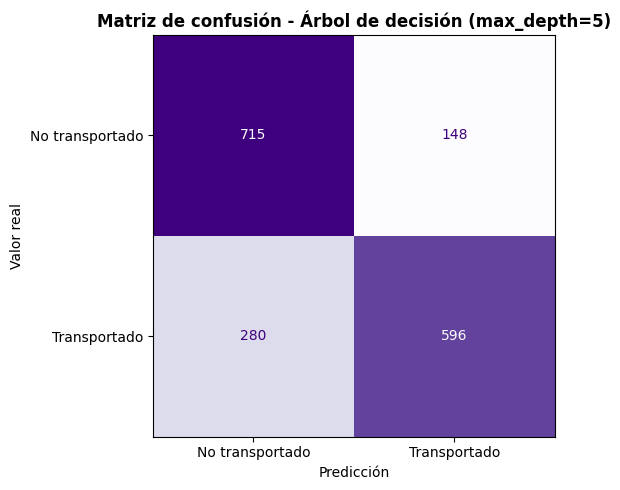

Falsos negativos (transportados no detectados): 280
Falsos positivos (no transportados marcados como transportados): 148


In [79]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_arbol,
    display_labels=['No transportado', 'Transportado'],
    cmap='Purples',
    colorbar=False,
    ax=ax
)

ax.set_title('Matriz de confusión - Árbol de decisión (max_depth=5)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor real')

plt.tight_layout()
plt.show()

print(f"Falsos negativos (transportados no detectados): {res_arbol['FN']}")
print(f"Falsos positivos (no transportados marcados como transportados): {res_arbol['FP']}")

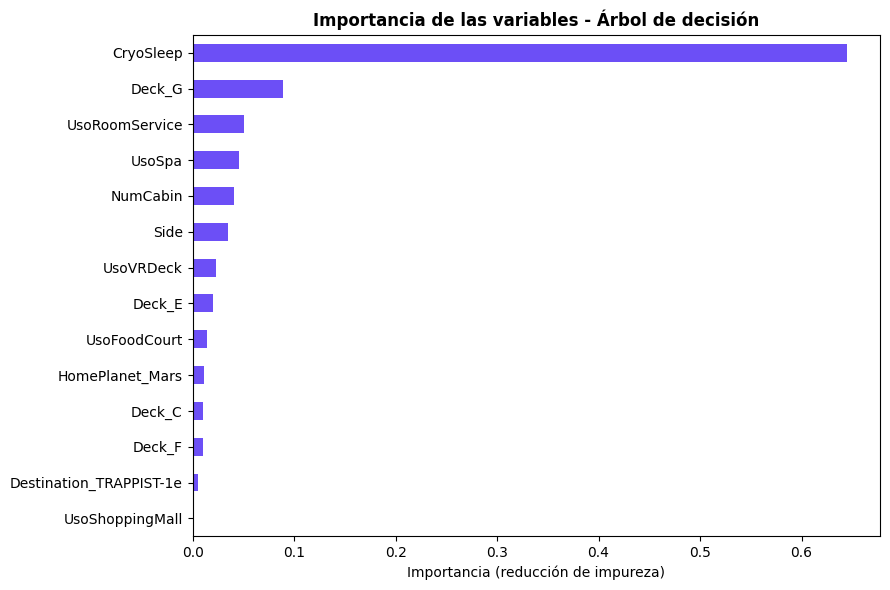

Variables no utilizadas por el árbol:
['Destination_PSO J318.5-22', 'HomePlanet_Europa', 'Deck_D', 'Deck_B', 'Deck_T', 'NumCabin_bin']


In [80]:
importancias = pd.Series(arbol.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
importancias[importancias > 0].sort_values().plot(kind='barh', ax=ax, color='#6C4FF6')
ax.set_title('Importancia de las variables - Árbol de decisión',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia (reducción de impureza)')
plt.tight_layout()
plt.show()

print('Variables no utilizadas por el árbol:')
print(importancias[importancias == 0].index.tolist())

In [81]:
from sklearn.tree import export_text

print(export_text(arbol, feature_names=list(X_train.columns), max_depth=2))

|--- CryoSleep <= 0.50
|   |--- UsoRoomService <= 0.50
|   |   |--- UsoSpa <= 0.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- UsoSpa >  0.50
|   |   |   |--- truncated branch of depth 3
|   |--- UsoRoomService >  0.50
|   |   |--- UsoFoodCourt <= 0.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- UsoFoodCourt >  0.50
|   |   |   |--- truncated branch of depth 3
|--- CryoSleep >  0.50
|   |--- Deck_G <= 0.50
|   |   |--- Deck_E <= 0.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- Deck_E >  0.50
|   |   |   |--- truncated branch of depth 3
|   |--- Deck_G >  0.50
|   |   |--- NumCabin <= -0.33
|   |   |   |--- truncated branch of depth 3
|   |   |--- NumCabin >  -0.33
|   |   |   |--- truncated branch of depth 3




El modelo supera el baseline con claridad. El accuracy pasa de 0.5037 a 0.7539 y el ROC-AUC de 0.5 a 0.8179. Ese salto en AUC es la evidencia más fuerte de que el árbol aprendió estructura real: no solo acierta más, sino que ordena a los pasajeros por probabilidad de haber sido transportados de una forma que el baseline no podía.

No hay sobreajuste. El accuracy en train es 0.7502 y en test 0.7539, prácticamente idénticos, con el test incluso ligeramente por encima. La restricción de max_depth cumplió su función: con 32 hojas el árbol generaliza en lugar de memorizar. Como referencia del riesgo que se evitó, un árbol sin límite de profundidad sobre estos mismos datos alcanza más de 2000 hojas y 0.98 de accuracy en train, y su desempeño en test cae por debajo de 0.69.

El modelo comete 280 falsos negativos contra 148 falsos positivos: casi el doble de errores en una dirección que en la otra. Esto se refleja en la separación entre precision, 0.8011, y recall, 0.6804. En términos concretos, el árbol es conservador para declarar que un pasajero fue transportado: cuando lo afirma acierta 4 de cada 5 veces, pero deja escapar a casi un tercio de los transportados reales. La specificity de 0.8285, muy por encima del recall, confirma el sesgo: el modelo es notablemente mejor identificando a quienes se quedaron que a quienes fueron transportados.

 El sesgo tiene una explicación en la estructura del árbol y no es un defecto arbitrario. El primer corte del modelo es CryoSleep, que concentra el 64.5% de la importancia total. Los pasajeros en hibernación se transportan en una proporción muy alta, así que esa rama es fácil y el árbol la resuelve bien. El problema está del otro lado: entre los pasajeros despiertos, el árbol se apoya en los indicadores de gasto, principalmente UsoRoomService y UsoSpa, que separan pero con mucho menos fuerza. Un pasajero despierto que además gastó poco cae en una zona ambigua donde el modelo tiende a predecir no transportado, y ahí se acumulan los falsos negativos.

el modelo aprendió bien la regla dominante del dataset, que hibernar predice ser transportado, y le cuesta el resto. Como este problema no tiene costo asimétrico entre los dos tipos de error, ese desequilibrio no es grave en sí mismo, pero sí marca dónde queda margen de mejora: el terreno a ganar está en los pasajeros despiertos, no en los dormidos.

Seis columnas tienen importancia cero, entre ellas varias dummies de Deck y de HomePlanet. No significa que no tengan relación con el target, sino que con profundidad 5 el árbol agota su presupuesto de cortes antes de llegar a ellas, y que parte de su información ya está capturada por las variables que sí usó. Es una consecuencia directa de la restricción de profundidad.

### 3.2 Regresión logística